In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [3]:
DATA_DIR = r'/home/pcdm/Desktop/indoor/Images'
model_algo="alexnet"

In [4]:

transform=transforms.Compose([
    transforms.Resize((229,229)),    
    transforms.ToTensor() 
])

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)
test_size = int(0.1 * size)
train_size = int(size - valid_size - test_size)

trainset, validset, testset = random_split(images, (train_size, valid_size, test_size), generator=generator)


In [6]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [7]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_3.pth')

In [8]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.20965870705441536, 0.9566489848179989)

In [9]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(1.45324721333312, 0.6097951344430218)

In [10]:
each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
each_accu

airport_inside    0.921114
artstudio         0.959596
auditorium        0.991304
bakery            0.960000
bar               0.949153
                    ...   
tv_studio         0.952381
videostore        0.987179
waitingroom       0.738318
warehouse         0.976608
winecellar        0.974227
Length: 67, dtype: float64

In [11]:
targetF=[x  for x in each_accu.nsmallest(24).index.map(trainset.dataset.classess)]
targetF

[64,
 42,
 46,
 47,
 40,
 22,
 11,
 60,
 38,
 20,
 27,
 21,
 0,
 44,
 23,
 54,
 37,
 50,
 55,
 24,
 35,
 25,
 5,
 4]

In [12]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(3955, 6979)

In [13]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(1100, 2024)

In [14]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [15]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [16]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.5996198511568485,train_accu=0.6879458569599415
Epoch=0,valid_loss=0.6181883560100072,valid_accu=0.6648527528809219
0
Epoch=1,train_loss=0.4901153106281259,train_accu=0.770440826778855
Epoch=1,valid_loss=0.573128579978601,valid_accu=0.689820742637644
0
Epoch=2,train_loss=0.4037922822417344,train_accu=0.8217486738613499
Epoch=2,valid_loss=0.5722794748756858,valid_accu=0.7087067861715749
0
Epoch=3,train_loss=0.38093278647417644,train_accu=0.8238522041338943
Epoch=3,valid_loss=0.6582695643361491,valid_accu=0.6843790012804097
Epoch=4,train_loss=0.2851712100980529,train_accu=0.8810133528443388
Epoch=4,valid_loss=0.6937463352225349,valid_accu=0.6690140845070423
Epoch=5,train_loss=0.18635683779565382,train_accu=0.9356136820925554
Epoch=5,valid_loss=0.6731493810380161,valid_accu=0.6939820742637645
Epoch=6,train_loss=0.1722144402338024,train_accu=0.9325955734406438
Epoch=6,valid_loss=0.7594363404755098,valid_accu=0.6830985915492958
4 Early stopping!


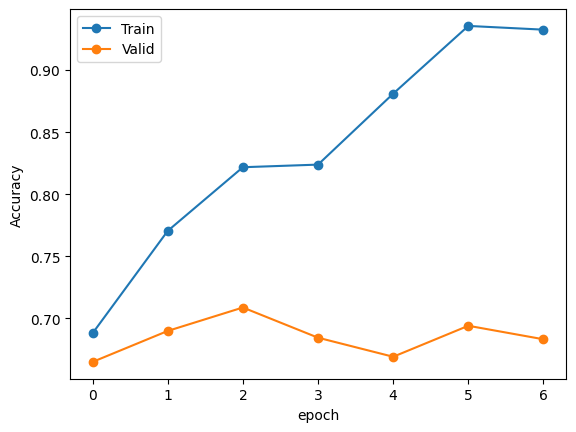

In [17]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

Epoch=0,train_loss=0.9047061962885952,train_accu=0.7324831637770455
Epoch=0,valid_loss=1.243547721342607,valid_accu=0.6368577075098815
0
Epoch=1,train_loss=0.6081808871996746,train_accu=0.8207479581601949
Epoch=1,valid_loss=1.156761934634725,valid_accu=0.6541501976284585
0
Epoch=2,train_loss=0.2900838753541333,train_accu=0.9213354348760567
Epoch=2,valid_loss=1.0852515956629878,valid_accu=0.6887351778656127
0
Epoch=3,train_loss=0.18329074923047825,train_accu=0.9499928356498065
Epoch=3,valid_loss=1.124732546184374,valid_accu=0.6803359683794467
Epoch=4,train_loss=0.1027225012260994,train_accu=0.9690500071643502
Epoch=4,valid_loss=1.2319898171858354,valid_accu=0.6902173913043478
0
Epoch=5,train_loss=0.06442613096607214,train_accu=0.9840951425705688
Epoch=5,valid_loss=1.1925583587804802,valid_accu=0.6946640316205533
0
Epoch=6,train_loss=0.022879738306597588,train_accu=0.9964178249032812
Epoch=6,valid_loss=1.0952958660163428,valid_accu=0.7282608695652174
0
Epoch=7,train_loss=0.03009114859951

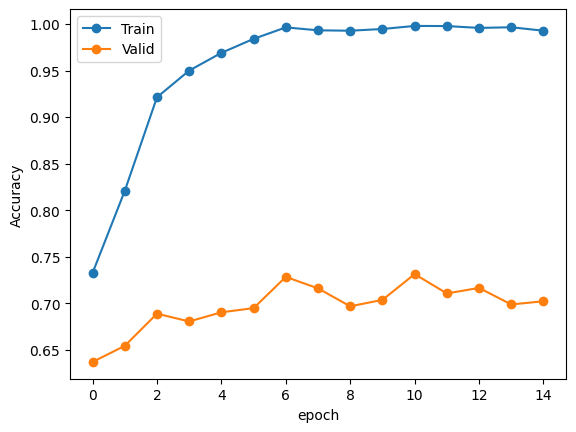

In [18]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=1.136510032287289,train_accu=0.6561314791403287
Epoch=0,valid_loss=1.4461660437150434,valid_accu=0.55
0
Epoch=1,train_loss=0.7514435545382397,train_accu=0.7906447534766119
Epoch=1,valid_loss=1.302101162997159,valid_accu=0.6045454545454545
0
Epoch=2,train_loss=0.40456698170277927,train_accu=0.8988621997471555
Epoch=2,valid_loss=1.254908939925107,valid_accu=0.6018181818181818
Epoch=3,train_loss=0.21143112631724245,train_accu=0.9512010113780025
Epoch=3,valid_loss=1.2726264416087758,valid_accu=0.6227272727272727
0
Epoch=4,train_loss=0.10331839384456953,train_accu=0.9739570164348925
Epoch=4,valid_loss=1.4007462557879362,valid_accu=0.6318181818181818
0
Epoch=5,train_loss=0.0531356204776788,train_accu=0.9891276864728192
Epoch=5,valid_loss=1.4855990652604536,valid_accu=0.6381818181818182
0
Epoch=6,train_loss=0.04419292152332973,train_accu=0.9916561314791403
Epoch=6,valid_loss=1.4982457650791514,valid_accu=0.63
Epoch=7,train_loss=0.019638777320307364,train_accu=0.997724399494

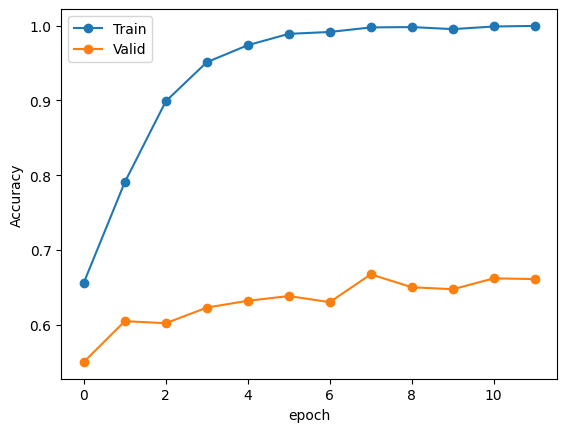

In [19]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [20]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.4037922822417344, 0.8217486738613499)

In [21]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.5722794748756858, 0.7087067861715749)

In [22]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.010652949881091297, 0.9979939819458375)

In [23]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.0196387775948768, 0.997724399494311)

In [24]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(1.2169714610096023, 0.7312252964426877)

In [25]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.4288871492039075, 0.6672727272727272)

In [26]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum_all=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum_all

(0.013903529351386026, 0.9978964697274556, 3955)

In [27]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum_all=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum_all

(1.2915851311250166, 0.7087067861715749, 1100)

In [28]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(3.2580949687556546, 0.8201024327784892, 3572, 7362)

In [29]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(6.1096292787568975, 0.5179257362355953, 1000, 2124)

In [30]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [31]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.209659,0.956649,1.453247,0.609795
1,Model_Decision,0.403792,0.821749,0.403792,0.708707
2,Model_T,0.010653,0.997994,1.216971,0.731225
3,Model_F,0.019639,0.997724,1.428887,0.667273
4,Total_Model,3.258095,0.820102,6.109629,0.517926
5,Total_Model_without_decision,0.013904,0.997896,1.291585,0.708707


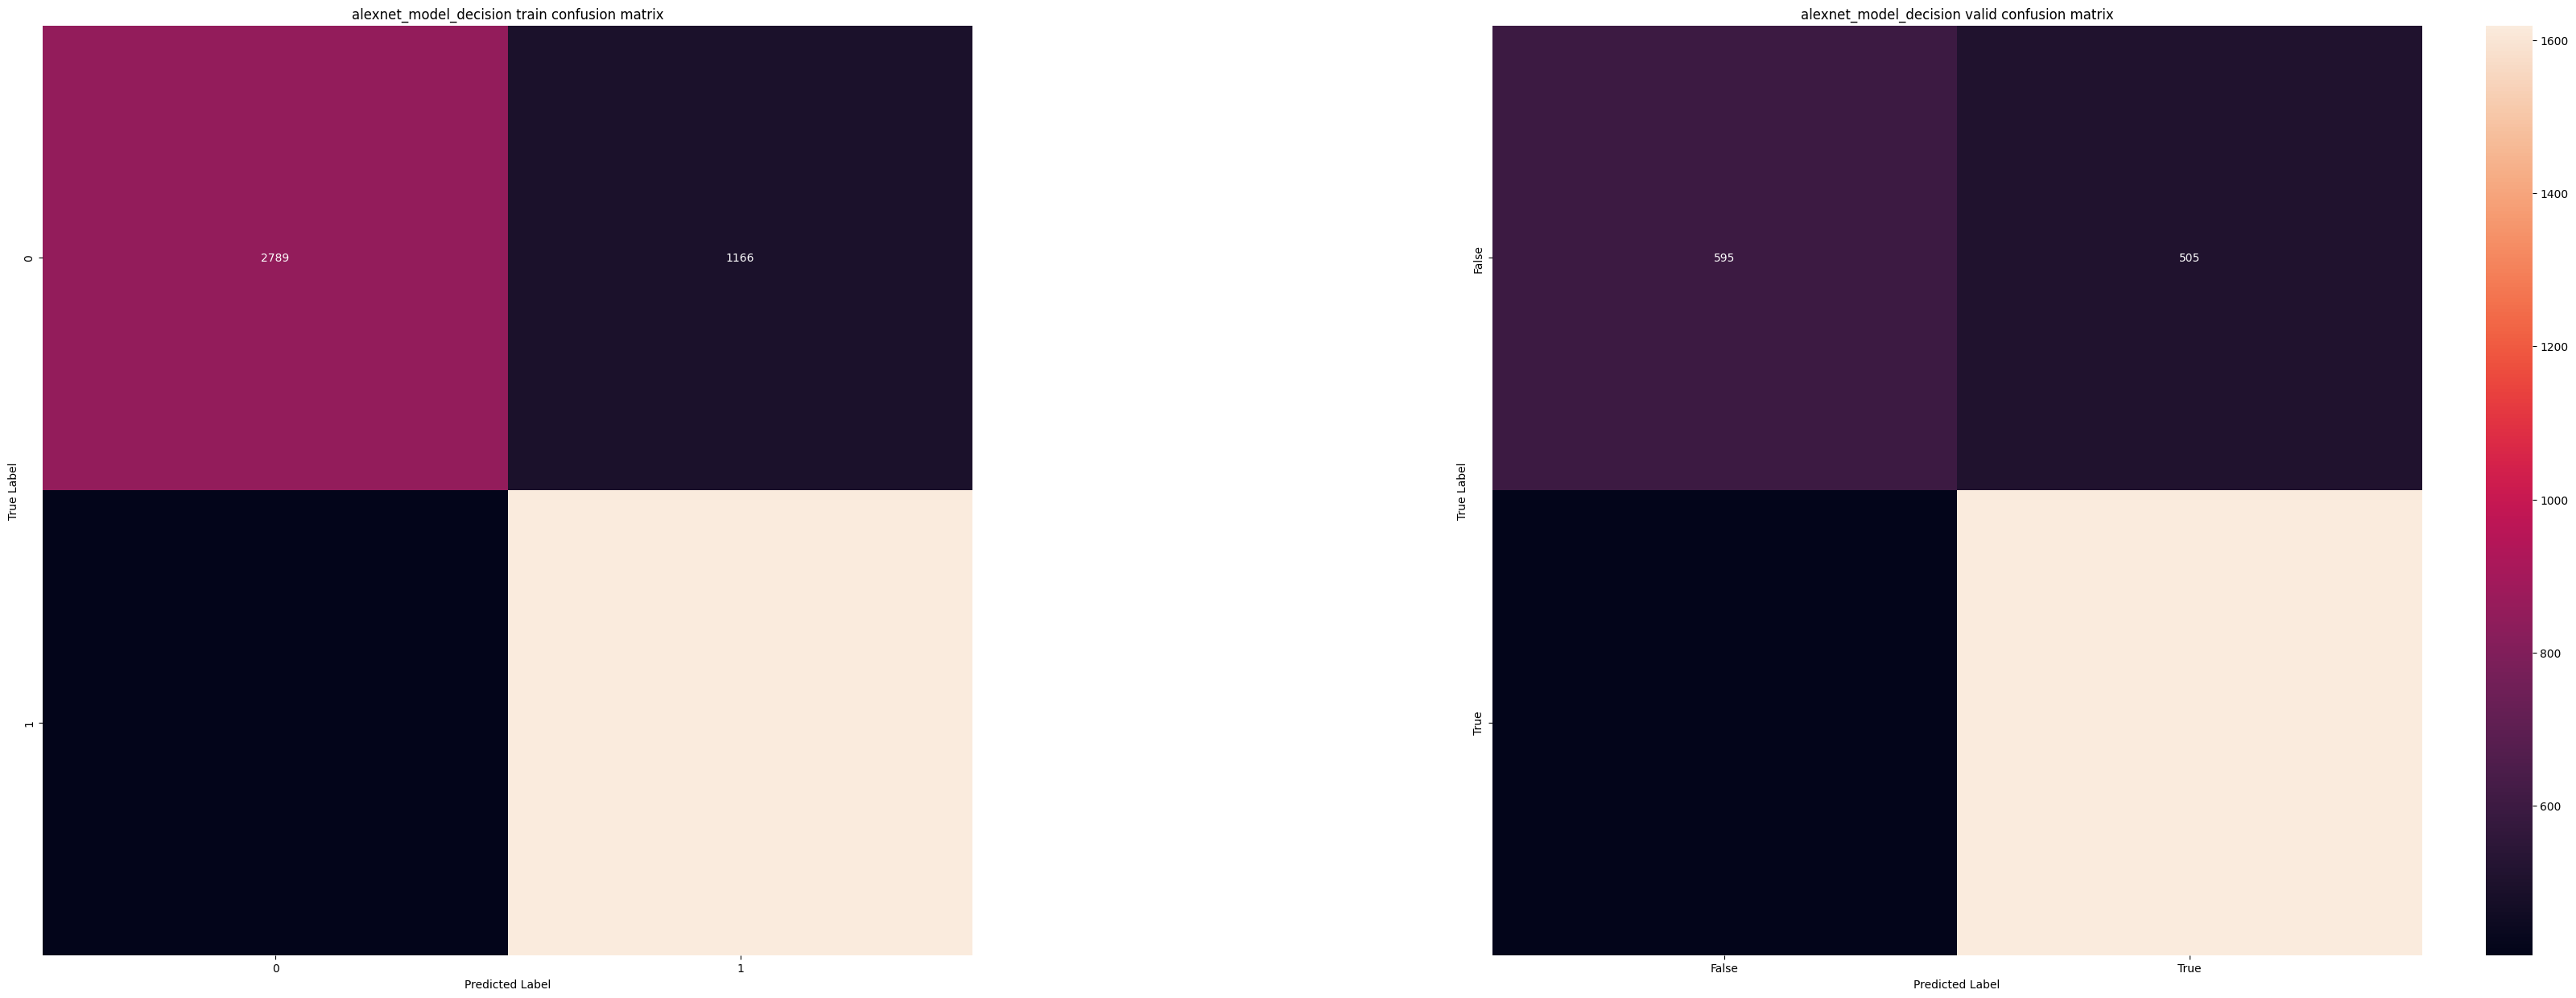

In [32]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

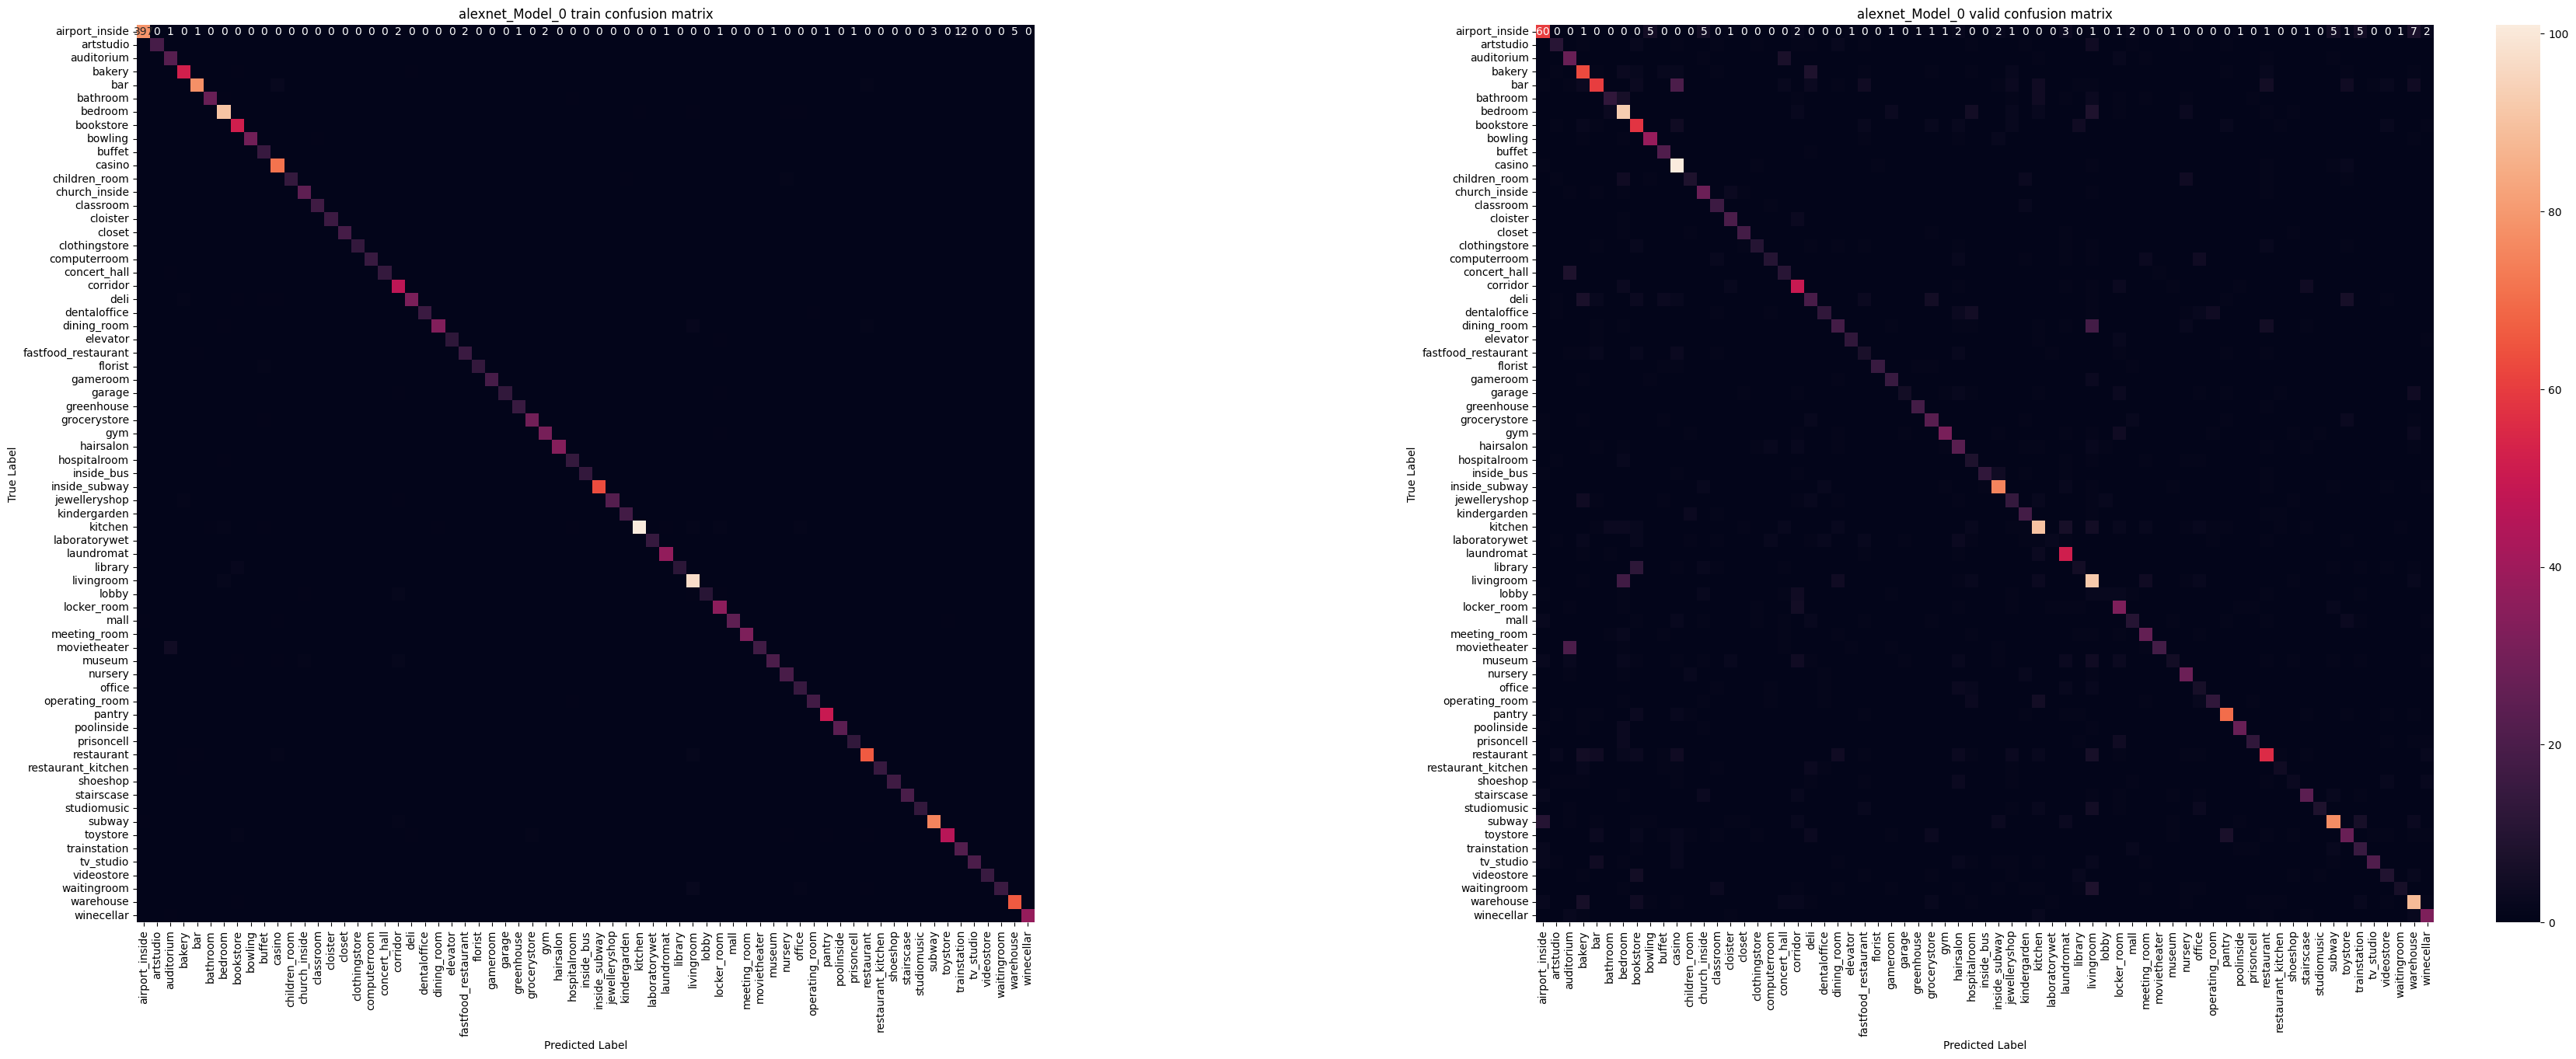

In [33]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

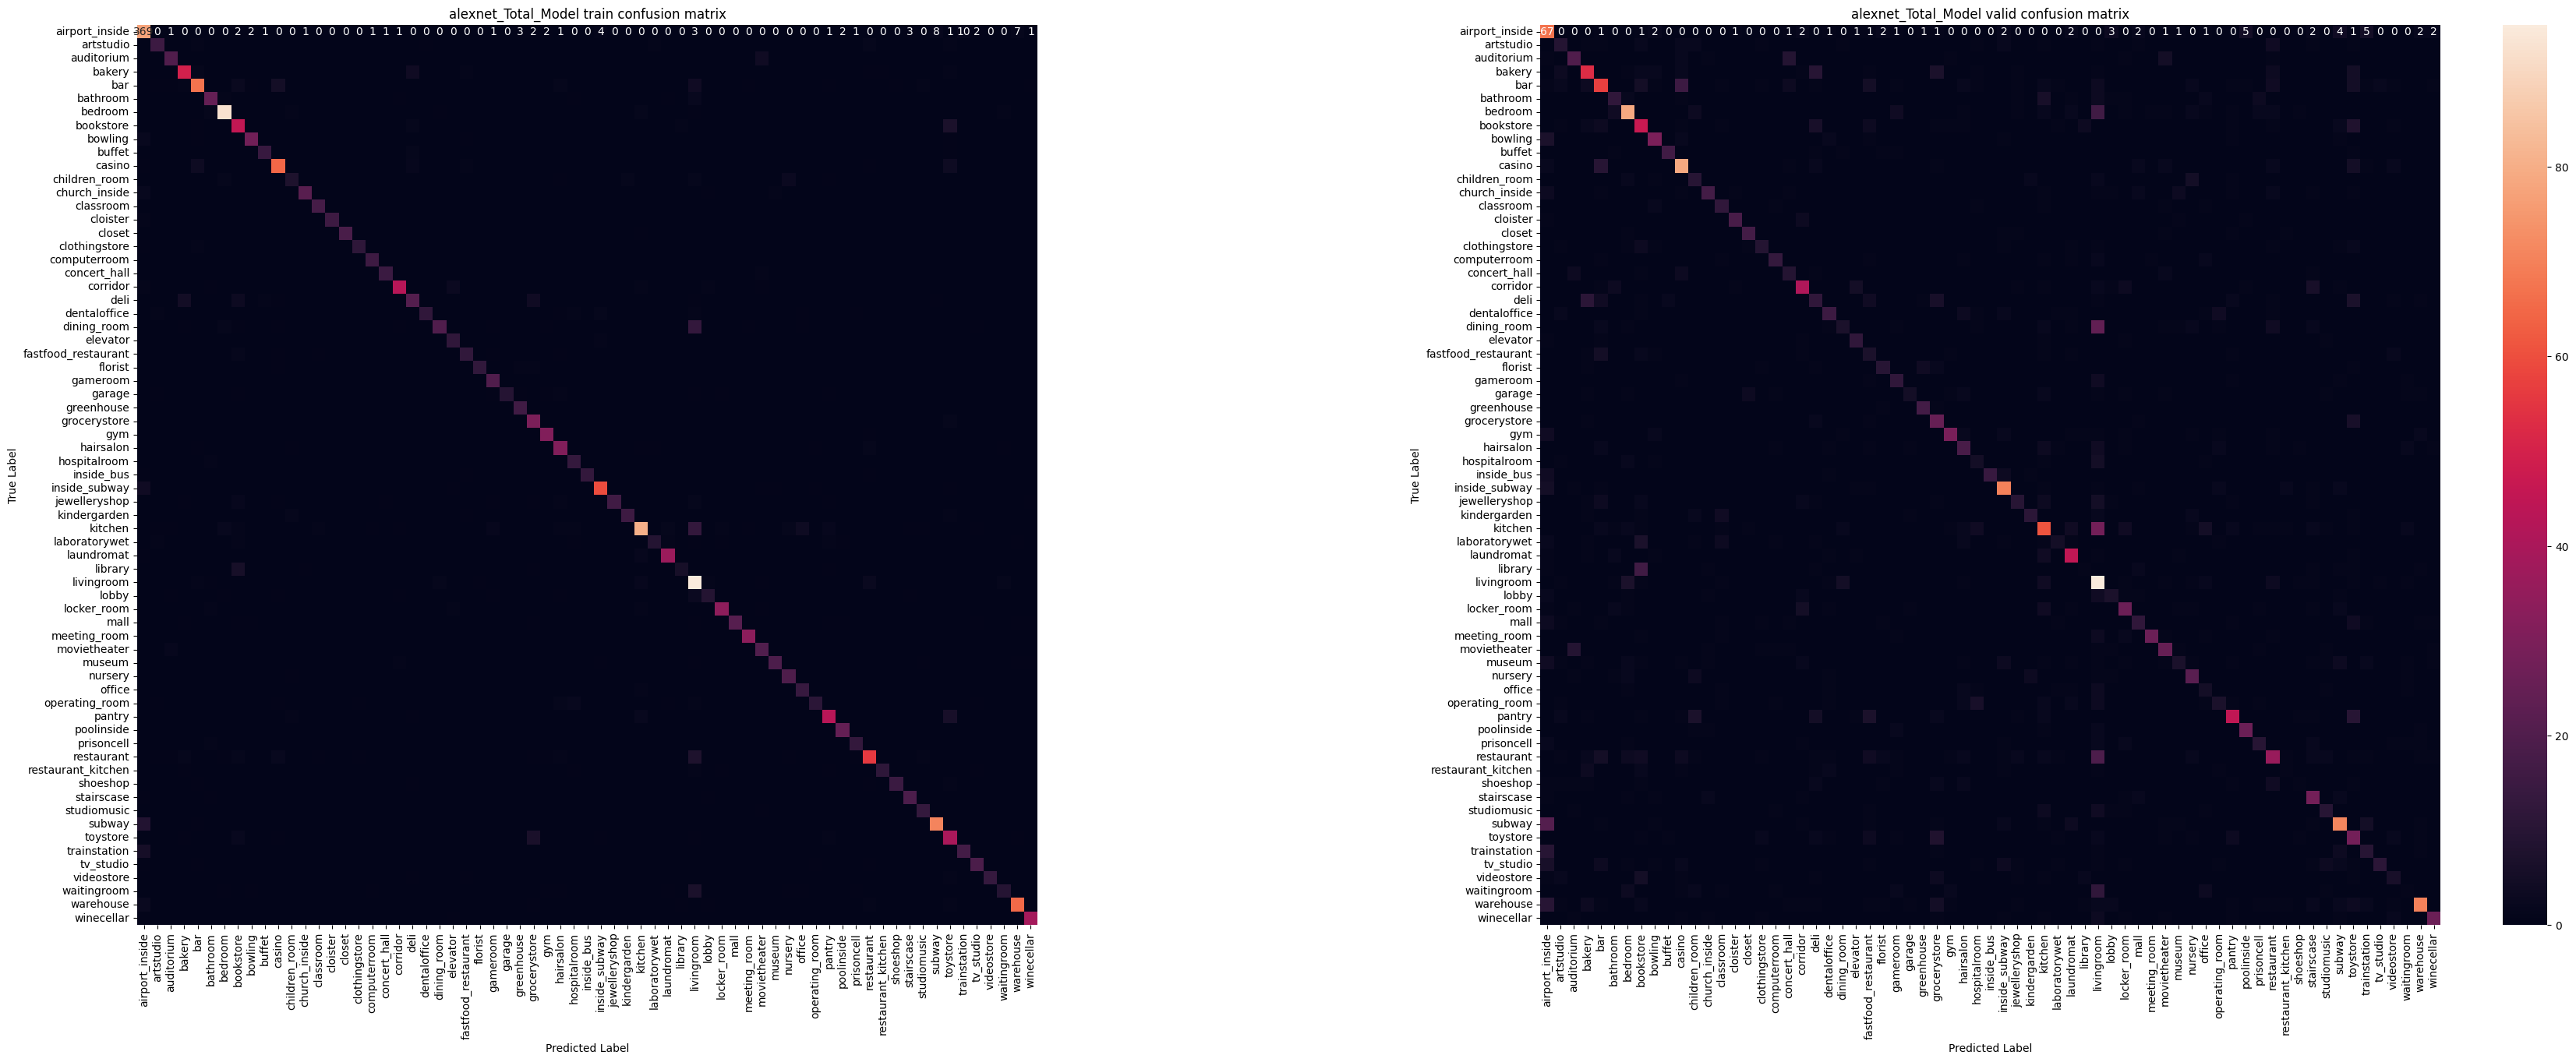

In [34]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

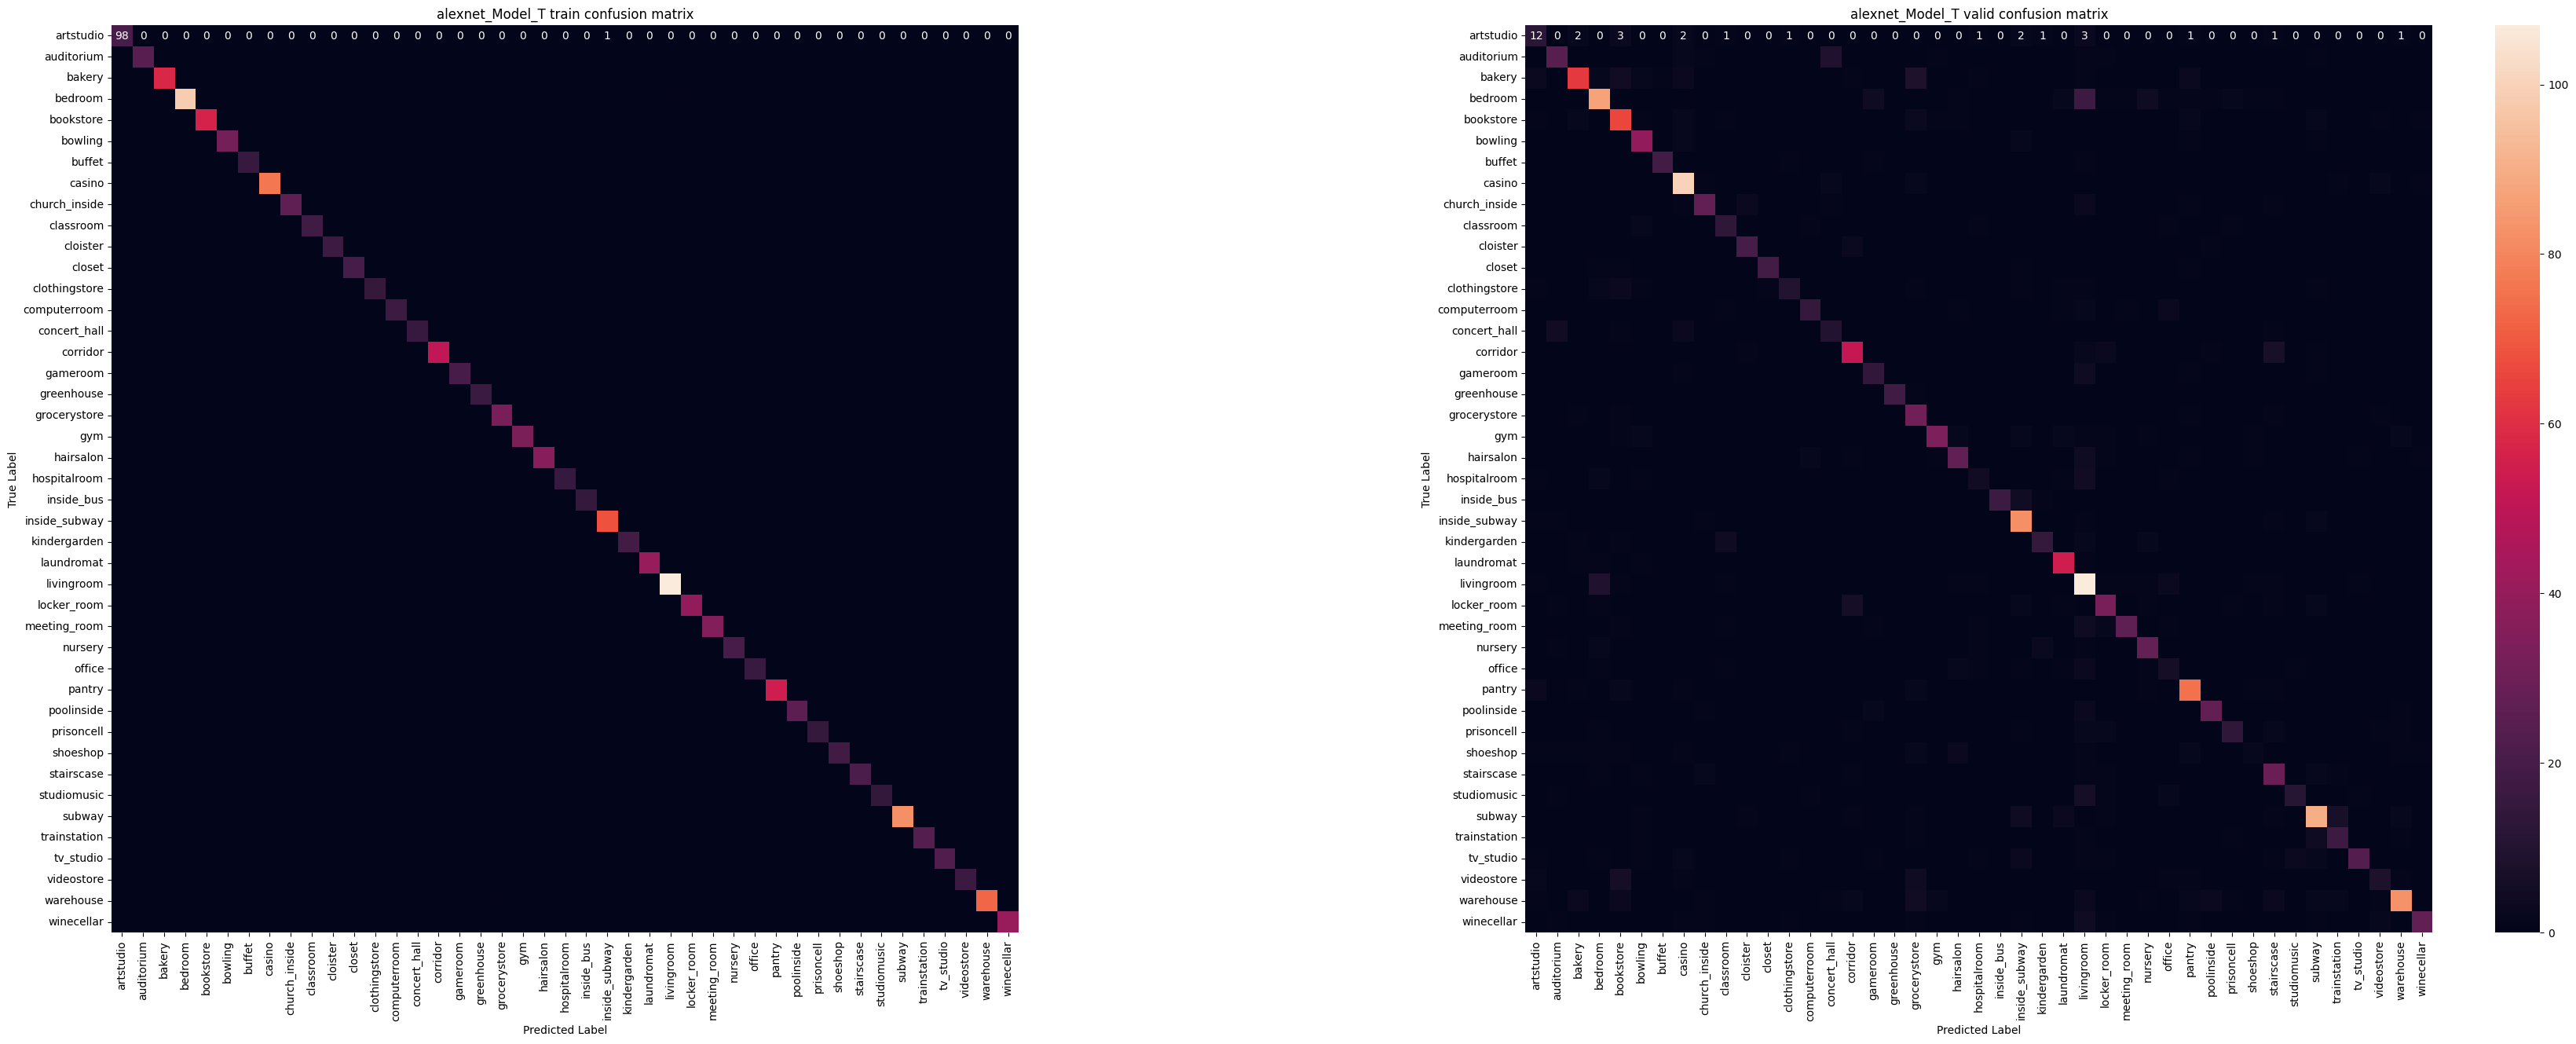

In [35]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

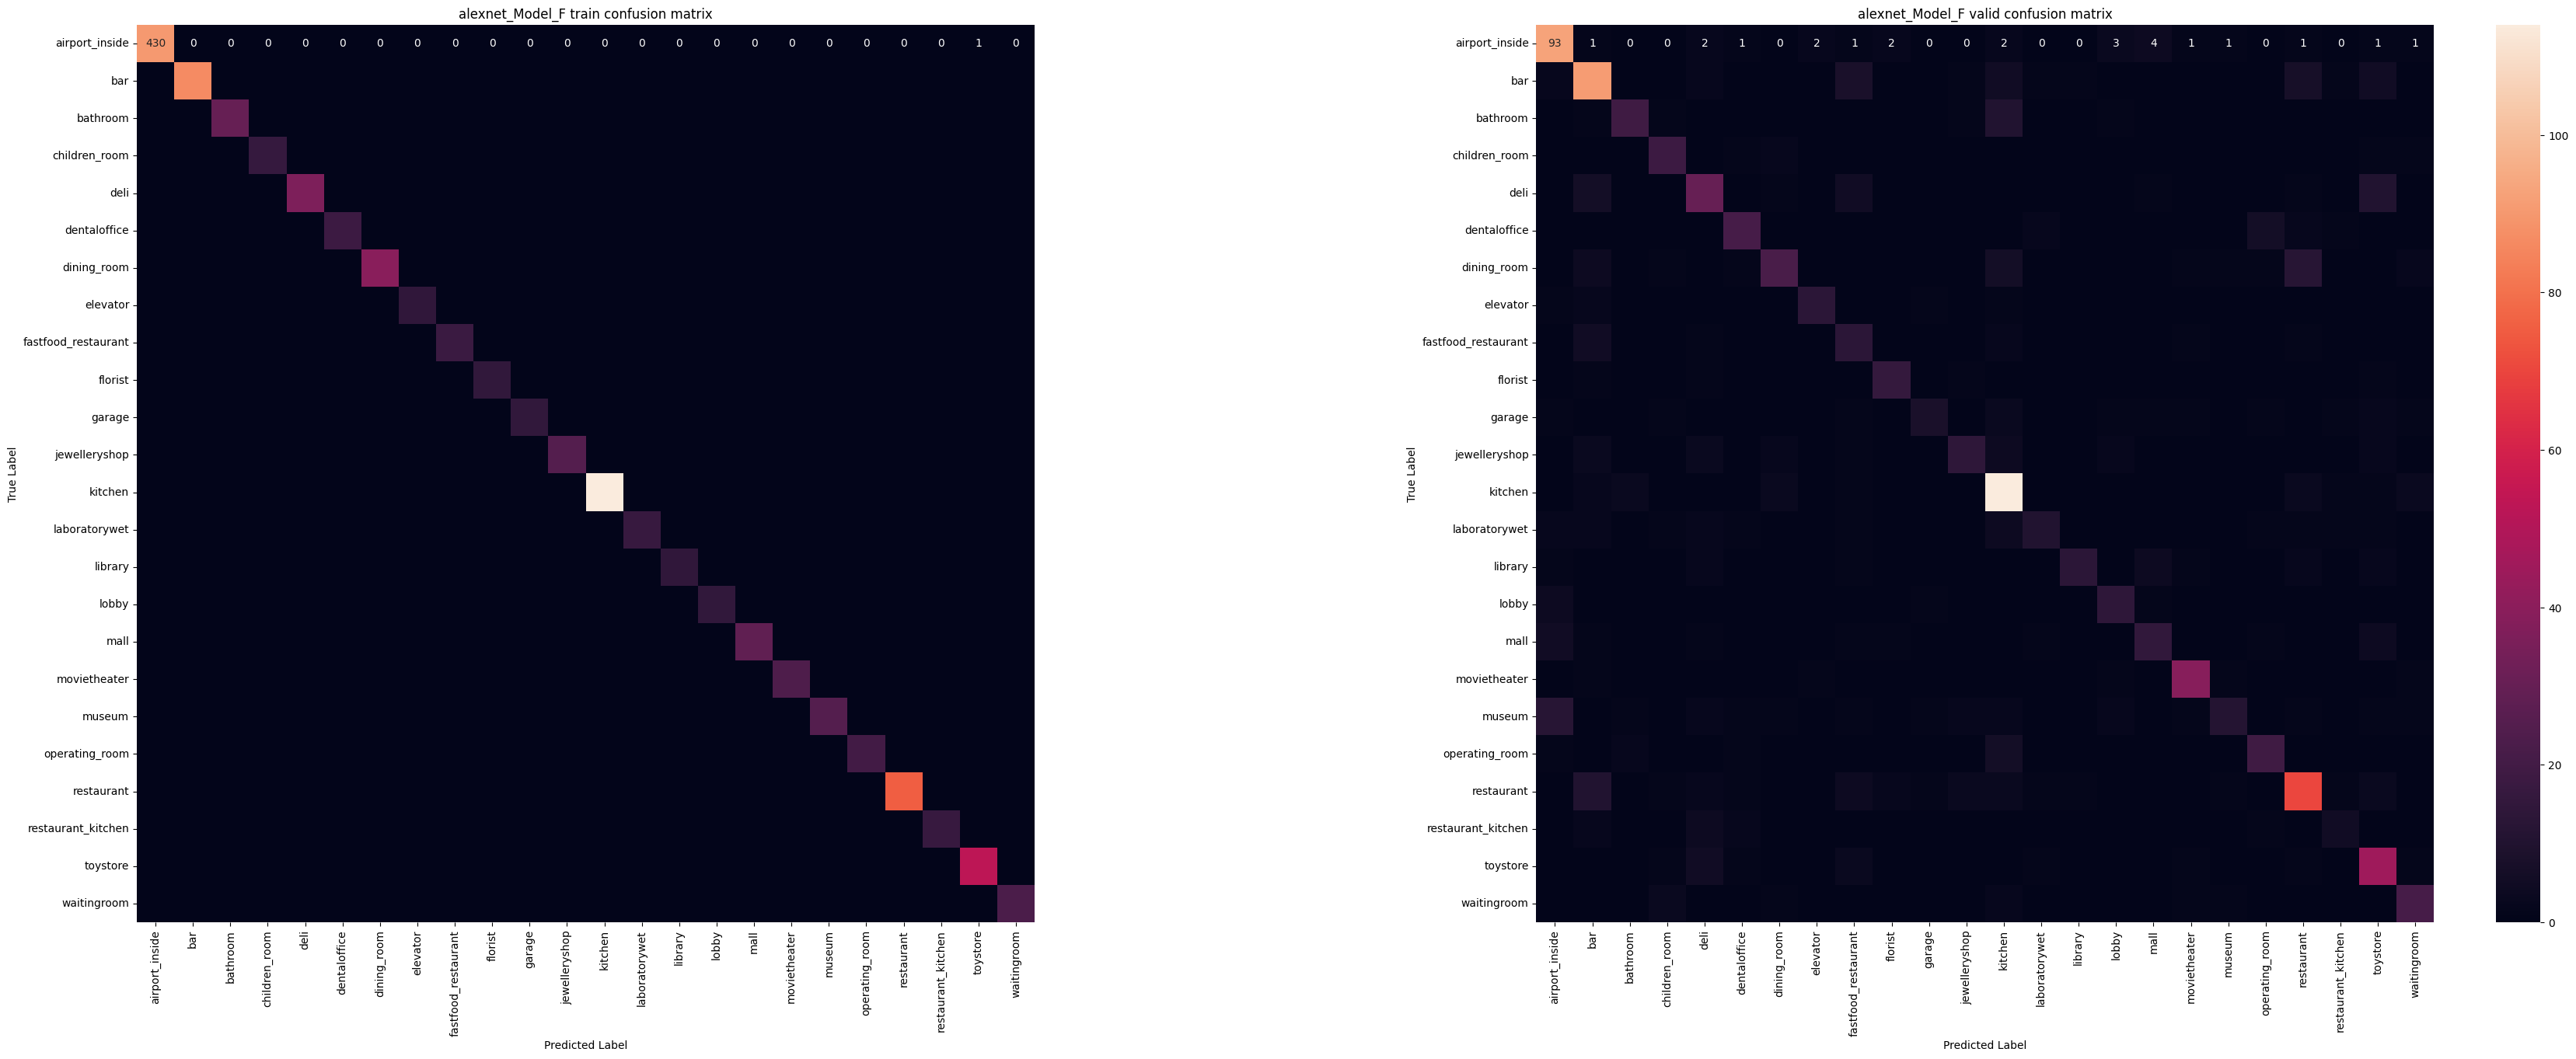

In [36]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [37]:
#全部模型裝在一起的表現
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                pred_F=torch.max(model_F(d.unsqueeze(0)), dim = 1).indices.item()
                pred_T=torch.max(model_T(d.unsqueeze(0)), dim = 1).indices.item()
                pred_0=torch.max(model_0(d.unsqueeze(0)), dim = 1).indices.item()
                
                    # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item()
                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [38]:
def calculate_lcb(data_dl,model):

    softmax_max_list = []

    # 计算每张图片的 softmax 最大值并添加到列表中
    with torch.no_grad():
        for images, labels,idx in data_dl:
            images = images.to(device)
            outputs = model(images)
            softmax_outputs = torch.softmax(outputs, dim=1)
            max_values, _ = torch.max(softmax_outputs, dim=1)
            softmax_max_list.extend(max_values.cpu().numpy())

    # 计算平均值
    avg = sum(softmax_max_list)/len(softmax_max_list)
    std = torch.tensor(softmax_max_list).std().item()

    lcb=avg-std

    return lcb,avg,std


In [39]:
##TT
lcb_T,avg_T,std_T=calculate_lcb(Tdl,model_T)
lcb_T,avg_T,std_T

(0.9567722167031337, 0.9922186519162227, 0.03544643521308899)

In [40]:
#FT
lcb_T,avg_T,std_T=calculate_lcb(Fdl,model_T)
lcb_T,avg_T,std_T

(0.5071476155979142, 0.735932653592299, 0.22878503799438477)

In [41]:
##FF
lcb_F,avg_F,std_F=calculate_lcb(Fdl,model_F)
lcb_F,avg_F,std_F

(0.9406882554471644, 0.9844191216111334, 0.04373086616396904)

In [42]:
##TF
lcb_F,avg_F,std_F=calculate_lcb(Tdl,model_F)
lcb_F,avg_F,std_F

(0.5169651702928209, 0.7384962634133958, 0.22153109312057495)

In [43]:
lcb_T_v,avg_T_v,std_T_v=calculate_lcb(Tdl_v,model_T)
lcb_T_v,avg_T_v,std_T_v

(0.6752811478958889, 0.8675291048870846, 0.19224795699119568)

In [44]:
lcb_F_v,avg_F_v,std_F_v=calculate_lcb(Fdl_v,model_F)
lcb_F_v,avg_F_v,std_F_v

(0.6305624142424627, 0.8329512819783255, 0.20238886773586273)

In [45]:
def draw_lcb(data_dl,model):

    softmax_max_list = []
    # 计算每张图片的 softmax 最大值并添加到列表中
    with torch.no_grad():
        for images, labels,idx in data_dl:
            images = images.to(device)
            outputs = model(images)
            softmax_outputs = torch.softmax(outputs, dim=1)
            max_values, _ = torch.max(softmax_outputs, dim=1)
            softmax_max_list.extend(max_values.cpu().numpy())
            
    # 計算 softmax 分佈的數量
    num_bins = 10  # 分成10個區間
    hist, bins = np.histogram(softmax_max_list, bins=num_bins)

    # 繪製直方圖
    plt.bar(bins[:-1], hist, width=(bins[1]-bins[0]))
    plt.xlabel('Softmax Value')
    plt.ylabel('Frequency')
    plt.title('Softmax Distribution')
    plt.show()

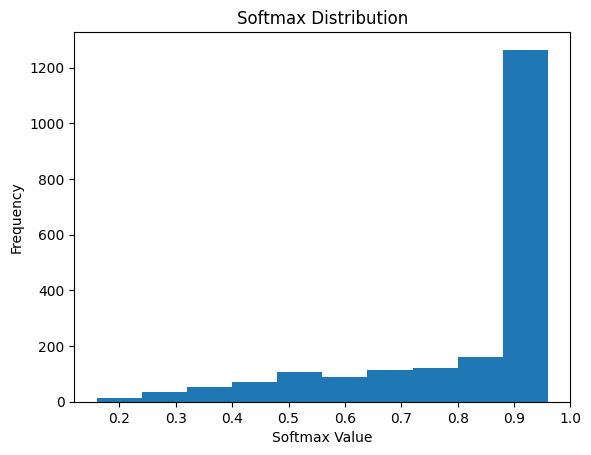

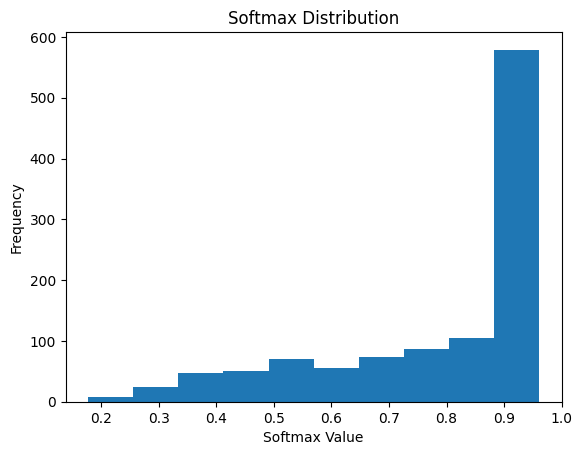

In [46]:
draw_lcb(Tdl_v,model_T)
draw_lcb(Fdl_v,model_F)

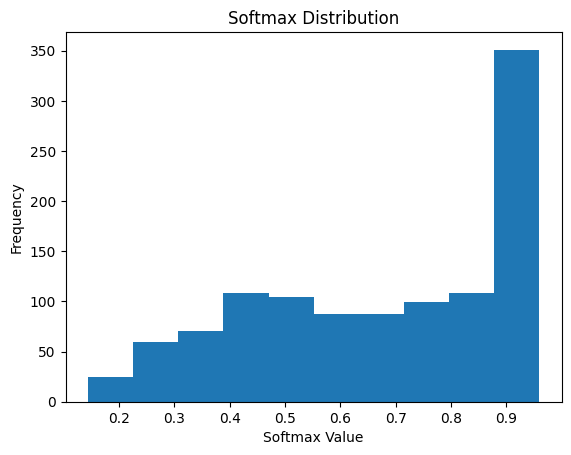

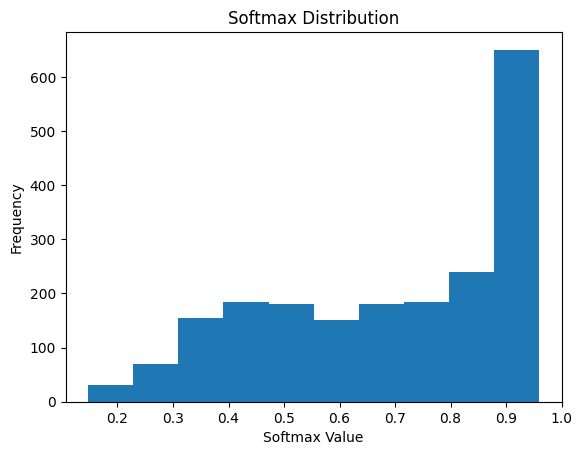

In [47]:
draw_lcb(Fdl_v,model_T)
draw_lcb(Tdl_v,model_F)

In [48]:
def calculate_lcb_simple(data_dl,avg_T,std_T,avg_F,std_F,size):
    simple_list = []
    # 计算每张图片的 softmax 最大值并添加到列表中
    with torch.no_grad():
        sum=0
        for images, labels,idx in data_dl:
            images = images.to(device)
            out_T = model_T(images)
            softmax_T = torch.softmax(out_T, dim=1)
            max_values_T, _ = torch.max(softmax_T, dim=1)
            value_T=max_values_T.cpu().numpy()


            out_F = model_F(images)
            softmax_F = torch.softmax(out_F, dim=1)
            max_values_F, _ = torch.max(softmax_F, dim=1)
            value_F=max_values_F.cpu().numpy()


            for value_T,value_F,idx in zip(value_T,value_F,idx):
                if (value_T>value_F):
                    flag=True
                else:
                    flag=False
                if (flag==data_dl.dataset.dataset.flag[idx]):
                    sum+=1
        
        sum=sum/size
    print(sum)
          

In [49]:
calculate_lcb_simple(train_dl,avg_T,std_T,avg_F,std_F,train_size)

0.9301262118163527


In [50]:
calculate_lcb_simple(valid_dl,avg_T,std_T,avg_F,std_F,valid_size)

0.704225352112676


In [51]:
features=[]
idxs=[]
for images,targe,idx in train_dl:
    features_batch = images.view(images.size(0), -1)
    features.extend(features_batch.cpu().numpy())
    idxs.extend(idx.cpu().numpy())

In [52]:
features = np.array(features)
idxs = np.array(idxs)

In [61]:
from sklearn.cluster import KMeans
n_clusters = len(trainset.dataset.classes)//2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(features)

labels = kmeans.labels_

for i in range(n_clusters):
    print(f"Cluster {i}: {np.sum(labels == i)} samples")

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Cluster 0: 380 samples
Cluster 1: 256 samples
Cluster 2: 462 samples
Cluster 3: 320 samples
Cluster 4: 306 samples
Cluster 5: 271 samples
Cluster 6: 432 samples
Cluster 7: 264 samples
Cluster 8: 408 samples
Cluster 9: 300 samples
Cluster 10: 354 samples
Cluster 11: 291 samples
Cluster 12: 280 samples
Cluster 13: 296 samples
Cluster 14: 232 samples
Cluster 15: 391 samples
Cluster 16: 260 samples
Cluster 17: 232 samples
Cluster 18: 286 samples
Cluster 19: 338 samples
Cluster 20: 264 samples
Cluster 21: 367 samples
Cluster 22: 341 samples
Cluster 23: 348 samples
Cluster 24: 299 samples
Cluster 25: 393 samples
Cluster 26: 356 samples
Cluster 27: 244 samples
Cluster 28: 422 samples
Cluster 29: 470 samples
Cluster 30: 310 samples
Cluster 31: 426 samples
Cluster 32: 335 samples


In [62]:
from collections import defaultdict

label_indices_dict = defaultdict(list)


for i, label in enumerate(labels):
    label_indices_dict[label].append(idxs[i])

sum_all=0

for label, indices in label_indices_dict.items():
    # print(f"Label {label} indices:", indices)
   
    trainsubset = Subset(trainset.dataset, indices)


    subset_loader = DataLoader(trainsubset, batch_size=batch_size, shuffle=True)

    # 计算 LCB
    lcb_T,_,_ = calculate_lcb(subset_loader, model_T)
    lcb_F,_,_ = calculate_lcb(subset_loader, model_F)
    if(lcb_T>lcb_F):
        for data,label,idx in subset_loader:
            for idx in idx:
                if(train_dl.dataset.dataset.flag[idx]==True):
                    sum_all+=1
    else:
        for data,label,idx in subset_loader:
            for idx in idx:
                if(train_dl.dataset.dataset.flag[idx]==False):
                    sum_all+=1    

sum_all=sum_all/train_size
sum_all  
    

0.6344430217669654

### 畫Tdl and Fdl 在model_0的softmax值

In [55]:
def draw_lcb(data_dl):

    softmax_group_true = []
    softmax_group_false=[]
    # 计算每张图片的 softmax 最大值并添加到列表中
    with torch.no_grad():
        for images, labels,idx in data_dl:
            images = images.to(device)
            outputs = model_0(images)
            softmax_outputs = torch.softmax(outputs, dim=1)
            max_values, _ = torch.max(softmax_outputs, dim=1)
            for idx,softmax in zip(idx,max_values):
                if(data_dl.dataset.dataset.flag[idx]==True):
                    softmax_group_true.append(softmax.cpu().numpy())
                else:
                    softmax_group_false.append(softmax.cpu().numpy())

            
    # 計算 softmax 分佈的數量
    num_bins = 10  # 分成10個區間
    hist, bins = np.histogram(softmax_group_true, bins=num_bins)

    # 繪製直方圖
    plt.bar(bins[:-1], hist, width=(bins[1]-bins[0]))
    plt.xlabel('Softmax Value')
    plt.ylabel('Frequency')
    plt.title('Softmax Distribution')
    plt.show()

        # 計算 softmax 分佈的數量
    num_bins = 10  # 分成10個區間
    hist, bins = np.histogram(softmax_group_false, bins=num_bins)

    # 繪製直方圖
    plt.bar(bins[:-1], hist, width=(bins[1]-bins[0]))
    plt.xlabel('Softmax Value')
    plt.ylabel('Frequency')
    plt.title('Softmax Distribution')
    plt.show()

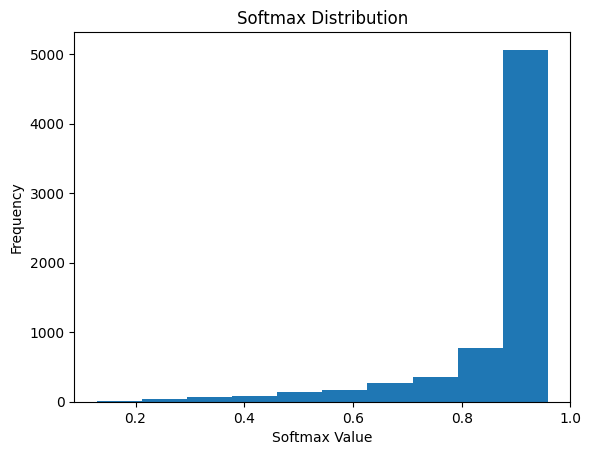

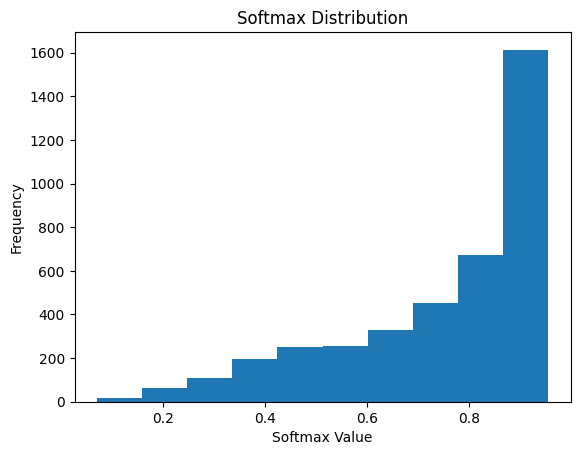

In [56]:
draw_lcb(train_dl)